## Q1: Biggest predictor of CO₂ output

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


In [2]:
def clean_df(df, cols):
    df = df[cols].dropna().copy()
    return df

In [3]:
df_gdp =pd.read_csv("https://ourworldindata.org/grapher/co2-emissions-vs-gdp.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_gdp = df_gdp[df_gdp['year'] >= 2000].copy()

df_gdp = df_gdp[~df_gdp['entity'].isin(['World', 'Europe', 'Asia'])].copy()
cols_gdp = ['entity','year','gdp_per_capita','emissions_total_per_capita']

df_gdp = clean_df(df_gdp, cols_gdp)

df_gdp = df_gdp.rename(columns={
    'entity':'Country',
    'year':'Year',
    'gdp_per_capita':'GDP',
    'emissions_total_per_capita':'CO2'})

In [4]:
df_calories = pd.read_csv("https://ourworldindata.org/explorers/global-food.csv?v=1&csvType=full&useColumnShortNames=true&Food=All+food&Metric=Food+available+for+consumption&Per+capita=true&Unit=Kilocalories+per+day", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_calories = df_calories[df_calories['year'] >= 2000].copy()

df_calories = df_calories[~df_calories['entity'].isin(['World', 'Europe', 'Asia'])].copy()
cols_calories = ['entity','year','total__00002901__food_available_for_consumption__0664pc__kilocalories_per_day_per_capita']

df_calories = clean_df(df_calories, cols_calories)
df_calories = df_calories.rename(columns={
    'entity':'Country',
    'year':'Year',
    'total__00002901__food_available_for_consumption__0664pc__kilocalories_per_day_per_capita':'Calories'})

In [5]:
df_energy = pd.read_csv("https://ourworldindata.org/grapher/per-capita-energy-use.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_energy = df_energy[df_energy['year'] >= 2000].copy()

cols_energy = ['entity','year','primary_energy_consumption_per_capita__kwh']
df_energy = df_energy[~df_energy['entity'].isin(['World', 'Europe', 'Asia'])].copy()

df_energy = clean_df(df_energy, cols_energy)
df_energy = df_energy.rename(columns={
    'entity':'Country',
    'year':'Year',
    'primary_energy_consumption_per_capita__kwh':'Energy'})

In [6]:
workdf = pd.merge(df_gdp, df_calories, on=['Country', 'Year'], how='inner')
workdf = pd.merge(workdf, df_energy, on=['Country', 'Year'], how='inner')

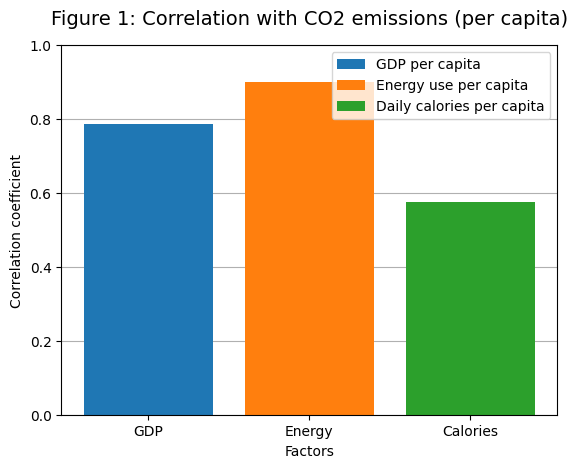

In [7]:
corr_gdp = workdf['GDP'].corr(workdf['CO2'])
corr_energy = workdf['Energy'].corr(workdf['CO2'])
corr_calories = workdf['Calories'].corr(workdf['CO2'])

values = [corr_gdp, corr_energy, corr_calories]
labels = ['GDP', 'Energy', 'Calories']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots()

bars1 = ax.bar(labels, values, color=colors)

ax.set_ylim(0, 1)
ax.set_xlabel('Factors')
ax.set_ylabel('Correlation coefficient')
ax.set_title('Figure 1: Correlation with CO2 emissions (per capita)', fontsize=14, pad=15)

ax.set_axisbelow(True)
ax.grid(axis='y')
ax.legend(bars1, ['GDP per capita', 'Energy use per capita', 'Daily calories per capita'])

plt.show()

##Q2: Biggest strides in decreasing CO2 output



In [8]:
df_decrease = workdf.copy()

first_year = df_decrease['Year'].min()
last_year = df_decrease['Year'].max()

In [9]:
start = df_decrease[df_decrease['Year'] == first_year][['Country', 'CO2']].rename(
    columns={'CO2': 'CO2_start'})

end = df_decrease[df_decrease['Year'] == last_year][['Country', 'CO2']].rename(
    columns={'CO2': 'CO2_end'})

trend = pd.merge(start, end, on= 'Country', how='inner')

In [10]:
trend['CO2_change'] = trend['CO2_end'] - trend['CO2_start']
trend['CO2_reduction_pct'] = -trend['CO2_change'] / trend['CO2_start'] * 100
trend = trend[trend['CO2_change'] < 0].copy()

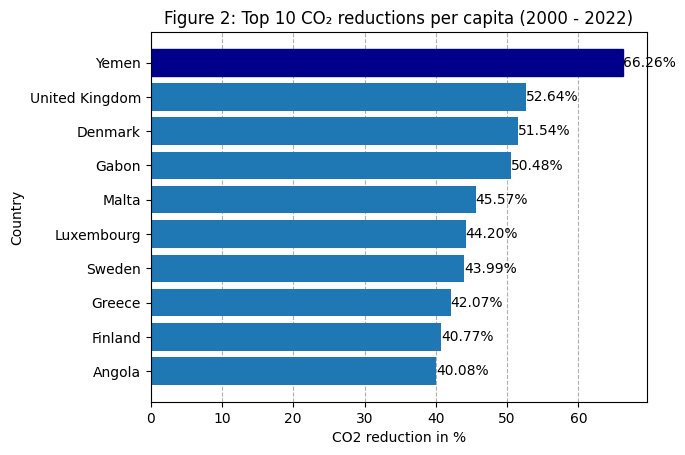

In [11]:
top10 = trend.sort_values(by='CO2_reduction_pct', ascending=False).head(10)

fig, ax = plt.subplots()

bars2 = ax.barh(top10['Country'], top10['CO2_reduction_pct'])
bars2[0].set_color('darkblue')
ax.set_xlabel('CO2 reduction in %')
ax.set_ylabel('Country')
ax.set_title(f'Figure 2: Top 10 CO₂ reductions per capita ({first_year} - {last_year})')

for i, v in enumerate(top10['CO2_reduction_pct']):
    ax.text(v, i, f'{v:.2f}%', ha='left', va='center')

ax.set_axisbelow(True)
ax.grid(axis='x', linestyle= '--')
ax.invert_yaxis()

plt.show()



##Q3: Best future price for non-fossil fuel energy


In [12]:
df_renewables = pd.read_csv("https://ourworldindata.org/grapher/levelized-cost-of-energy.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_renewables = df_renewables [(df_renewables['entity'] == 'World') & (df_renewables['year'] >= 2000)].copy()

cols_renewables = ['entity','year','solar_photovoltaic','hydropower','onshore_wind']

df_renewables = clean_df(df_renewables, cols_renewables)
df_renewables = df_renewables.rename(columns={
    'entity':'Country',
    'year':'Year',
    'solar_photovoltaic':'Solar',
    'hydropower':'Hydro',
    'onshore_wind':'Wind'})

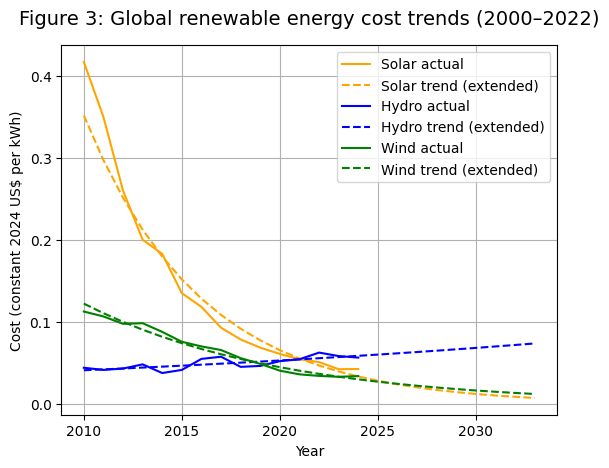

In [14]:
fig, ax = plt.subplots()

techs = ['Solar', 'Hydro', 'Wind']

colors = {
    'Solar': 'orange',
    'Hydro': 'blue',
    'Wind': 'green'
}

for tech in techs:

    color = colors[tech]

    x = df_renewables['Year'].values
    y = df_renewables[tech].values

    y_log = np.log(y)


    slope, intercept = np.polyfit(x, y_log, 1)

    x_future = np.arange(x.min(), 2034)
    y_future = np.exp(slope * x_future + intercept)

    ax.plot(x, y, color=color, label=f'{tech} actual')
    ax.plot(x_future, y_future, '--', color=color, label=f'{tech} trend (extended)')

ax.set_xlabel('Year')
ax.set_ylabel('Cost (constant 2024 US$ per kWh)')
ax.set_title('Figure 3: Global renewable energy cost trends (2000–2022)', fontsize=14, pad=15)
ax.legend()
ax.grid(True)

plt.show()